TRABAJO PRACTICO NUMERO 1


# **Vigilancia de Dengue y Zika - diciembre 2018**

In [ ]:
#importando el archivo
from pathlib import Path
import requests

archivo = Path("informacion-publica-dengue-zika-nacional-hasta-20181231.csv")
url = "http://datos.salud.gob.ar/dataset/ceaa8e87-297e-4348-84b8-5c643e172500/resource/255440b0-d8b2-4247-87d2-91dfec29eb0f/download/informacion-publica-dengue-zika-nacional-hasta-20181231.csv"
if not archivo.exists():
    r = requests.get(url)
    archivo.write_bytes(r.content)

In [ ]:
#Importando las bibliotecas necesarias para el proyecto
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so


#usando pandas para leer el csv y guardarlo en un dataframe
df = pd.read_csv('/content/informacion-publica-dengue-zika-nacional-hasta-20181231.csv')
#Chequeo que los datos esten correctamente guardados.
df

,departamento_id,departamento_nombre,provincia_id,provincia_nombre,ano,semanas_epidemiologicas,evento_nombre,grupo_edad_id,grupo_edad_desc,cantidad_casos
0,2003,COMUNA 3,2,CABA,2018,15,Dengue,6,de 10 a 14 anos,1
1,2004,COMUNA 4,2,CABA,2018,6,Dengue,6,de 10 a 14 anos,1
2,6091,Berazategui,6,Buenos Aires,2018,11,Dengue,7,de 15 a 24 anos,1
3,6091,Berazategui,6,Buenos Aires,2018,14,Dengue,9,de 25 a 34 anos,2
4,6091,Berazategui,6,Buenos Aires,2018,19,Dengue,11,de 45 a 65 anos,1
...,...,...,...,...,...,...,...,...,...,...
917,126,Orán,66,Salta,2018,20,Enfermedad por Virus del Zika,11,Mayor o igual de 65 anos,1
918,126,Orán,66,Salta,2018,21,Enfermedad por Virus del Zika,9,De 25 a 34 anos,1
919,126,Orán,66,Salta,2018,22,Enfermedad por Virus del Zika,6,De 10 a 14 anos,1
920,126,Orán,66,Salta,2018,23,Enfermedad por Virus del Zika,7,De 15 a 19 anos,1


**CANTIDAD TOTAL DE CASOS DENGUE/ZIKA EN 2018**

In [ ]:
# Puedo utilizar la funcion de numpy "np.sum()" y acceder a los datos de la columna "cantidad de casos" y asi conseguir rapido la cantidad de casos resgistrados en 2018.
# Guardo el valor de la suma total en una variable.
suma_total = np.sum(df["cantidad_casos"])
print(suma_total)

1613


Con la suma total de los valores registrados y la cantidad de valores registrados puedo obtener la MEDIA de la columna "cantidad_casos".

**MEDIA** = SumaDeTodosLosValores/CantidadDeValores.

En este caso la **suma total de valores** me dio 1613 y la **cantidad de valores** es 922, por lo que la **MEDIA** = 1613/922 => 1.749457701

**MEDIA Y DESVIACION ESTANDAR DE LAS COLUMNAS**

In [ ]:
tabla = df.pivot_table(
    index="evento_nombre",
    aggfunc={"semanas_epidemiologicas":["mean","std"], "cantidad_casos":["mean", "std"]}
)
tabla

cantidad_casos            \
                                        mean       std   
evento_nombre                                            
Dengue                              1.774775  1.583082   
Enfermedad por Virus del Zika       1.088235  0.287902   

                              semanas_epidemiologicas            
                                                 mean       std  
evento_nombre                                                    
Dengue                                      17.786036  5.222377  
Enfermedad por Virus del Zika               18.264706  3.752242

## **PREGUNTAS:**

<h1>¿Cual es la provincia con mas casos registrados de Dengue/Zika en 2018? ¿Y la provincia con menos casos?<h1>

In [ ]:
#agrupo por separado el maximo y el minimo con la funcion sum() y despues los uno en un nuevo dataframe
max = (df.groupby('provincia_nombre')[["cantidad_casos"]].sum()).idxmax()
min = (df.groupby('provincia_nombre')[["cantidad_casos"]].sum()).idxmin()

CasosRegistrados = pd.DataFrame()
CasosRegistrados["Provincia+Casos"] = max
CasosRegistrados["Provincia-Casos"] = min

print(CasosRegistrados)

               Provincia+Casos Provincia-Casos
cantidad_casos           Chaco         Mendoza


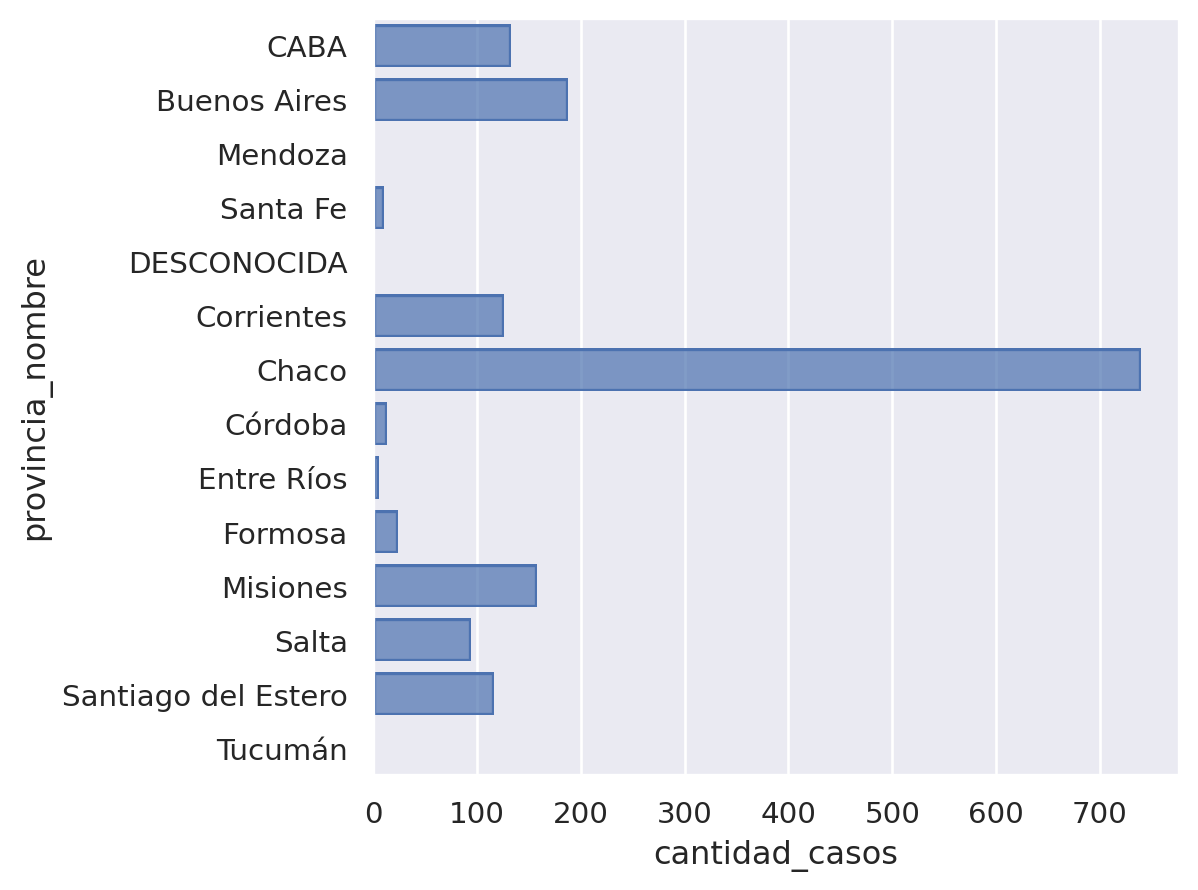

In [ ]:
so.Plot(data=df, x="cantidad_casos", y="provincia_nombre").add(so.Bar(), so.Agg("sum"))

<h1>¿Cual es la mayor cantidad de casos registrados en una sola semana epidemiologica? ¿En que provincia ocurrio?<h1>

**¿Que es una semana epidemiologica?** Lapso entre el día domingo y día sabado siguiente.

Encuentro la cantidad maxima de casos registrados

In [ ]:
(
    df.groupby("cantidad_casos")
    .agg({"cantidad_casos": "idxmax"})
    .aggregate({"cantidad_casos": "idxmax"})
)

,0
cantidad_casos,12


Filtro en el dataset por el valor de cantidad maxima de casos registrados

In [ ]:
df[df["cantidad_casos"] == 12]

,departamento_id,departamento_nombre,provincia_id,provincia_nombre,ano,semanas_epidemiologicas,evento_nombre,grupo_edad_id,grupo_edad_desc,cantidad_casos
571,46063,General Belgrano,22,Chaco,2018,20,Dengue,10,de 35 a 44 anos,12


Con esta informacion me doy cuenta de que en realidad 12 es la cantidad de casos registrados en una misma semana epidemiologica, del mismo grupo de edad, cuando lo que quiero encontrar es la cantidad total de casos de todos los grupos de edades en la misma semana

In [ ]:
#Agregando el aggfunc={"cantidad_casos":["sum"]}, me aseguro de que sea la cantidad total de casos en distintos grupos de edades
tabla = df.pivot_table(
    index="semanas_epidemiologicas",
    columns="evento_nombre",
    aggfunc={"cantidad_casos":["sum"]}
)
tabla

cantidad_casos                              
                                   sum                              
evento_nombre                   Dengue Enfermedad por Virus del Zika
semanas_epidemiologicas                                             
1                                  3.0                           NaN
2                                  2.0                           NaN
3                                  1.0                           NaN
4                                  1.0                           NaN
5                                  4.0                           NaN
6                                  2.0                           NaN
7                                  4.0                           NaN
8                                  7.0                           NaN
9                                 13.0                           NaN
10                                20.0                           1.0
11                                32.0                           2.0
12                                39.0                           2.0
13                                44.0                           NaN
14                                64.0                           2.0
15                                59.0                           2.0
16                               137.0                           2.0
17                               182.0                           NaN
18                               200.0                           2.0
19                               275.0                           8.0
20                               233.0                           7.0
21                               118.0                           2.0
22                                54.0                           4.0
23                                41.0                           3.0
24                                12.0                           NaN
25                                 2.0                           NaN
26                                 8.0                           NaN
27                                 2.0                           NaN
28                                 3.0                           NaN
37                                 1.0                           NaN
38                                 1.0                           NaN
40                                 2.0                           NaN
41                                 1.0                           NaN
45                                 1.0                           NaN
46                                 1.0                           NaN
49                                 3.0                           NaN
50                                 3.0                           NaN
52                                 1.0                           NaN

**Hago un grafico para mostrar cual fue la provincia que mas casos registro en un periodo de tiempo**

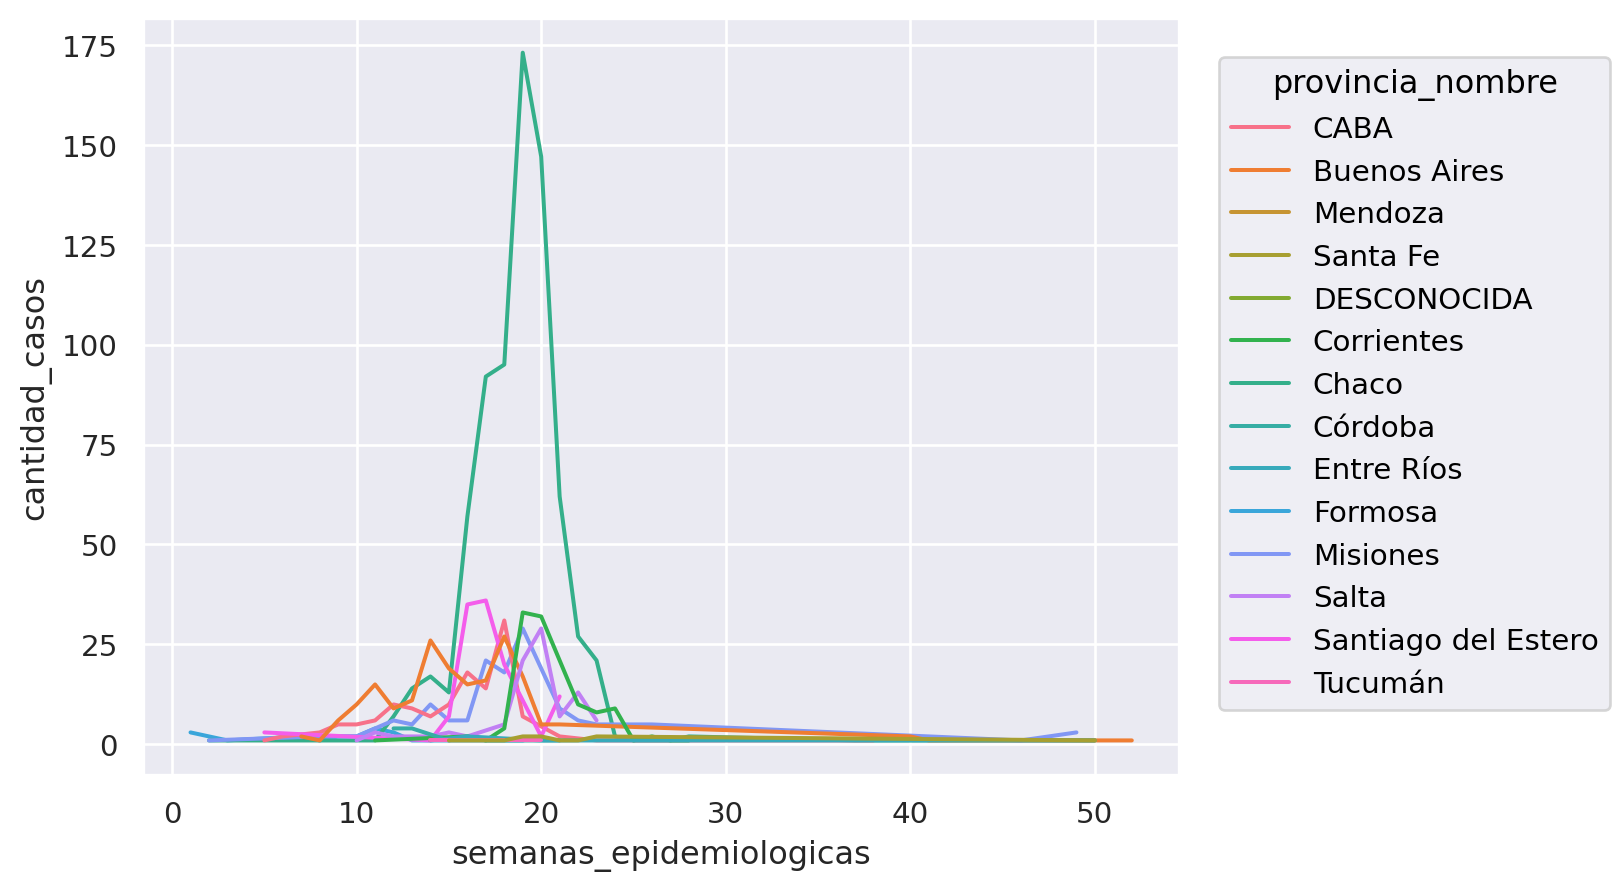

In [ ]:
(
so.Plot(data=df, x="semanas_epidemiologicas", y="cantidad_casos",color="provincia_nombre")
.add(so.Line(),so.Agg("sum"))
)

Se ve claramente como Chaco es la provincia con mas casos registrados, no solo en una semana si no que en todo el año.

<h1>¿Cuales son los grupos de edades mas afectados por estas enfermedades?<h1>

Tuve que separar en ambos casos, porque al ser dos enfermedades distintas los datos se mezclaban y no podia diferenciar entre Dengue y Zika.
Sin embargo, el error estaba en que los grupos de edades para la enfermedad de Zika empezaban con una mayuscula y para la enfermedad de Dengue estaban escritos en minuscula, era una inconsistencia en los valores de la columna que puedo solucionar de esta manera


In [ ]:
#transforma todos los valores a minuscula, de esta manera puedo hacer la tabla sin ningun inconveniente.
df["grupo_edad_desc"] = df["grupo_edad_desc"].str.lower()


In [ ]:
df_edades_dengue = df[df["evento_nombre"] == "Dengue"].groupby("grupo_edad_desc")["cantidad_casos"].sum()
df_edades_zika = (df[df["evento_nombre"] == "Enfermedad por Virus del Zika"].groupby("grupo_edad_desc")["cantidad_casos"].sum()).astype(int)
df_edades = pd.DataFrame()

df_edades["Dengue"] = df_edades_dengue
df_edades["Zika"] = df_edades_zika

df_edades_menor_a_mayor = df_edades.sort_values(by=["Dengue", "Zika"], ascending=[True, True])

df_edades_menor_a_mayor


,Dengue,Zika
grupo_edad_desc,,
igual a 1 ano,1,1.0
sin especificar,1,NaN
menor que 1 ano,3,1.0
posneonato (29 hasta 365 días),6,NaN
de 13 a 24 meses,8,1.0
mayor de 65 anos,17,NaN
de 2 a 4 anos,33,1.0
mayores de 65 anos,48,NaN
de 5 a 9 anos,81,2.0


**Grafico que lo representa.**

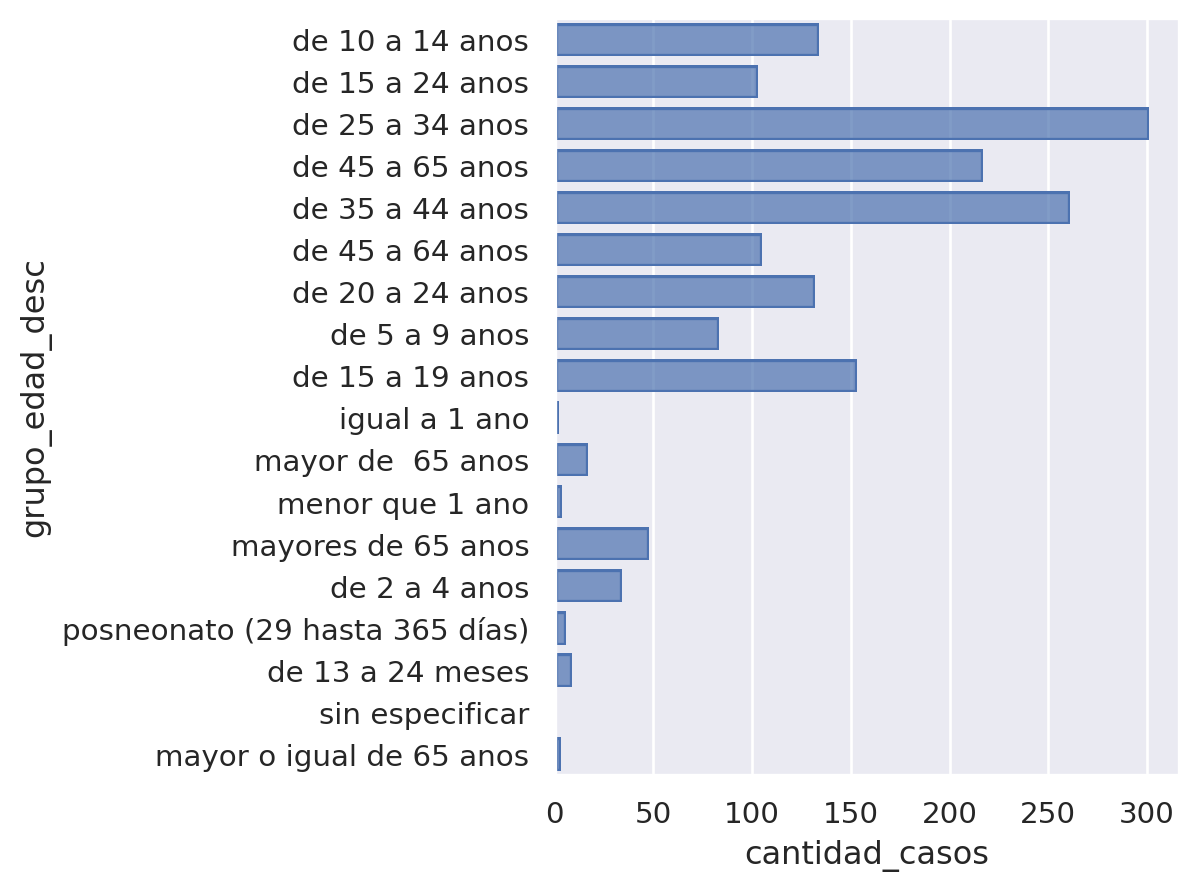

In [ ]:
df["grupo_edad_desc"] = df["grupo_edad_desc"].str.lower()
so.Plot(data=df, x="cantidad_casos", y="grupo_edad_desc").add(so.Bar(), so.Agg("sum"))

En esta tabla se puede apreciar como los grupos de edades mas afectados por el Dengue son los que se encuentran entre los 25 a 65 años, es interesante ya que es el rango de edad donde las personas son mucho mas activas y recurren a distintos lugares en un solo dia.
Sin embargo ningun grupo se salva del Dengue y se podria decir q todos corren el peligro de contraerlo.


Por otro lado el Zika es una enfermedad con menos casos registrados en 2018, siendo el grupo de 25 a 34 años con la mayor cantidad total de casos registrados.

<h1>Tabla q me muestra la cantidad de casos totales de ambas enfermedades por provincias, de forma ascendente <h1>

In [ ]:
tabla = df.pivot_table(
    index="provincia_nombre",
    columns="evento_nombre",
    aggfunc={"cantidad_casos":["sum"]}
)
tabla = tabla.sort_values(by=[('cantidad_casos', 'sum', 'Dengue'), ('cantidad_casos', 'sum', 'Enfermedad por Virus del Zika')], ascending=[True, True])
tabla

cantidad_casos                              
                               sum                              
evento_nombre               Dengue Enfermedad por Virus del Zika
provincia_nombre                                                
Mendoza                        1.0                           NaN
DESCONOCIDA                    2.0                           NaN
Tucumán                        2.0                           NaN
Entre Ríos                     6.0                           NaN
Santa Fe                      11.0                           NaN
Córdoba                       13.0                           NaN
Formosa                       24.0                           NaN
Salta                         58.0                          36.0
Santiago del Estero          116.0                           NaN
Corrientes                   126.0                           NaN
CABA                         133.0                           NaN
Misiones                     158.0                           NaN
Buenos Aires                 187.0                           1.0
Chaco                        739.0                           NaN

Tucuman y mendoza sin casos? Chubut no aparece tampoco(
al ser de Chubut tengo la experiencia y el conocimiento para afirmar que para esa epoca no existian los mosquitos que transmitan Dengue o Zika).